# Train ONE CNN+FNN to output the sheep's move direction (dx, dy)

The model reads the sheep's 3-channel egocentric view — **terrain** + **food** (grass) +
**threat** (fox) — and **outputs the `(dx, dy)` heading to move**, exactly the quantity
`RuleBrain` produces. A single model must handle **both** behaviours:

* **flee** (a fox is in the threat channel) → heading *away* from the fox, and
* **forage** (no fox) → heading *toward* the grass centre-of-mass.

We take one view per scene from `sheep_vision_dataset.csv` and regress toward the stored
`tgt_dx, tgt_dy`. On held-out scenes we check the output heading, **broken out by mode**, to
confirm the one model learns to both flee and forage.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

_here = Path.cwd()
REPO = next((c for c in [_here, *_here.parents]
             if (c / "config.py").exists() and (c / "sim").is_dir()), _here)
DATA_PATH = REPO / "notebooks" / "vision" / "sheep" / "sheep_vision_dataset.csv"
OUT_PATH  = REPO / "notebooks" / "vision" / "sheep" / "sheepvision.pth"

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| data:", DATA_PATH)

device: cuda | data: c:\Users\afree\Desktop\ecosystem\notebooks\vision\sheep\sheep_vision_dataset.csv


In [2]:
df = pd.read_csv(DATA_PATH)
WIN = int(round(int(df.columns.str.startswith("t_").sum()) ** 0.5))
t_cols = [f"t_{i}" for i in range(WIN * WIN)]
f_cols = [f"f_{i}" for i in range(WIN * WIN)]
x_cols = [f"x_{i}" for i in range(WIN * WIN)]

# One view per scene (the generator wrote several candidate-heading rows per scene, but the
# pixels are identical within a scene). Target = the stored true heading (dx, dy) -- the same
# quantity RuleBrain outputs: away from the fox (flee) or toward the grass mass (forage).
one = df.drop_duplicates("scenario_id", keep="first").reset_index(drop=True)
terr = one[t_cols].to_numpy(np.float32).reshape(-1, WIN, WIN)
food = one[f_cols].to_numpy(np.float32).reshape(-1, WIN, WIN)
thre = one[x_cols].to_numpy(np.float32).reshape(-1, WIN, WIN)
X = np.stack([terr, food, thre], axis=1)                       # (S, 3, WIN, WIN)
tgt = one[["tgt_dx", "tgt_dy"]].to_numpy(np.float32)
tgt /= np.linalg.norm(tgt, axis=1, keepdims=True) + 1e-9       # unit (dx, dy) target
mode = one["mode"].to_numpy(int)
print("scenes:", len(one), "| X:", X.shape, "| flee:", int(mode.sum()),
      "| forage:", int((mode == 0).sum()))

scenes: 1000 | X: (1000, 3, 25, 25) | flee: 500 | forage: 500


In [3]:
# Random train/val split over scenes (one row per scene -> nothing to leak).
rng = np.random.default_rng(0)
order = rng.permutation(len(X))
n_val = max(1, int(0.2 * len(X)))
va, tr_ = order[:n_val], order[n_val:]
Xtr, ytr = torch.tensor(X[tr_]), torch.tensor(tgt[tr_])
Xva, yva = torch.tensor(X[va]), torch.tensor(tgt[va])
print(f"train scenes {len(Xtr)} | val scenes {len(Xva)}")

train scenes 800 | val scenes 200


In [4]:
class SheepVisionNet(nn.Module):
    """CNN over the 3-channel view (terrain, food, threat) -> FNN -> the (dx, dy) heading."""
    def __init__(self, in_channels=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(6),
            nn.Flatten(),
        )
        self.fnn = nn.Sequential(
            nn.Linear(32 * 6 * 6, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),                    # -> (dx, dy); normalized to a unit heading
        )
    def forward(self, grid):
        return self.fnn(self.cnn(grid))

model = SheepVisionNet().to(device)
print(model)
print("trainable params:", sum(p.numel() for p in model.parameters()))

SheepVisionNet(
  (cnn): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): AdaptiveAvgPool2d(output_size=6)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fnn): Sequential(
    (0): Linear(in_features=1152, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
trainable params: 170306


In [5]:
def unit(v):
    return v / (v.norm(dim=1, keepdim=True) + 1e-9)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
Xtr_d, ytr_d = Xtr.to(device), ytr.to(device)
Xva_d, yva_d = Xva.to(device), yva.to(device)

EPOCHS, BATCH = 60, 64
n = len(Xtr_d)
for ep in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(n, device=device)
    tot = 0.0
    for i in range(0, n, BATCH):
        b = perm[i:i+BATCH]
        pred = unit(model(Xtr_d[b]))
        loss = (1.0 - (pred * ytr_d[b]).sum(1)).mean()      # 1 - cosine similarity
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(b)
    if ep == 1 or ep % 5 == 0:
        model.eval()
        with torch.no_grad():
            vcos = (unit(model(Xva_d)) * yva_d).sum(1).mean().item()
        print(f"epoch {ep:2d}  train_loss {tot/n:.4f}   val cos(pred,true) {vcos:.4f}")

epoch  1  train_loss 0.8577   val cos(pred,true) 0.3152
epoch  5  train_loss 0.6730   val cos(pred,true) 0.4531
epoch 10  train_loss 0.6002   val cos(pred,true) 0.5249
epoch 15  train_loss 0.5253   val cos(pred,true) 0.6097
epoch 20  train_loss 0.0253   val cos(pred,true) 0.9763
epoch 25  train_loss 0.0107   val cos(pred,true) 0.9901
epoch 30  train_loss 0.0048   val cos(pred,true) 0.9932
epoch 35  train_loss 0.0034   val cos(pred,true) 0.9951
epoch 40  train_loss 0.0022   val cos(pred,true) 0.9953
epoch 45  train_loss 0.0025   val cos(pred,true) 0.9942
epoch 50  train_loss 0.0012   val cos(pred,true) 0.9973
epoch 55  train_loss 0.0007   val cos(pred,true) 0.9973
epoch 60  train_loss 0.0006   val cos(pred,true) 0.9973


## The proof — the output heading matches, for BOTH modes

The model's raw output **is** the `(dx, dy)` heading (we just normalize it). On held-out scenes
it should align with the true heading — and crucially, well **within each mode**: away from the
fox in flee scenes, toward the grass in forage scenes.

held-out scenes: 200
OVERALL  mean cos +0.997 | within 20deg 99.5% | median err 1.7 deg
FLEE     mean cos +0.999 | within 20deg 100.0% | median err 1.3 deg | n=92
FORAGE   mean cos +0.996 | within 20deg 99.1% | median err 2.4 deg | n=108


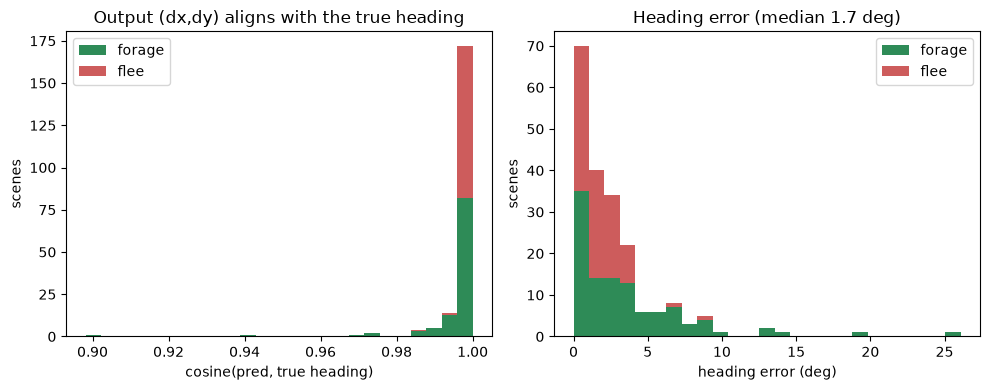

In [6]:
model.eval()
with torch.no_grad():
    pred = unit(model(Xva_d)).cpu().numpy()      # <- the model's (dx, dy) output
true = tgt[va]
cos = (pred * true).sum(1)
ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))
vmode = mode[va]
print(f"held-out scenes: {len(pred)}")
print(f"OVERALL  mean cos {cos.mean():+.3f} | within 20deg {np.mean(ang<=20)*100:.1f}% | "
      f"median err {np.median(ang):.1f} deg")
for m, name in ((1, "FLEE  "), (0, "FORAGE")):
    sel = vmode == m
    print(f"{name}   mean cos {cos[sel].mean():+.3f} | within 20deg "
          f"{np.mean(ang[sel]<=20)*100:.1f}% | median err {np.median(ang[sel]):.1f} deg "
          f"| n={int(sel.sum())}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist([cos[vmode==0], cos[vmode==1]], bins=25, stacked=True,
           color=["seagreen", "indianred"], label=["forage", "flee"])
ax[0].set_xlabel("cosine(pred, true heading)"); ax[0].set_ylabel("scenes"); ax[0].legend()
ax[0].set_title("Output (dx,dy) aligns with the true heading")
ax[1].hist([ang[vmode==0], ang[vmode==1]], bins=25, stacked=True,
           color=["seagreen", "indianred"], label=["forage", "flee"])
ax[1].set_xlabel("heading error (deg)"); ax[1].set_ylabel("scenes"); ax[1].legend()
ax[1].set_title(f"Heading error (median {np.median(ang):.1f} deg)")
plt.tight_layout(); plt.show()

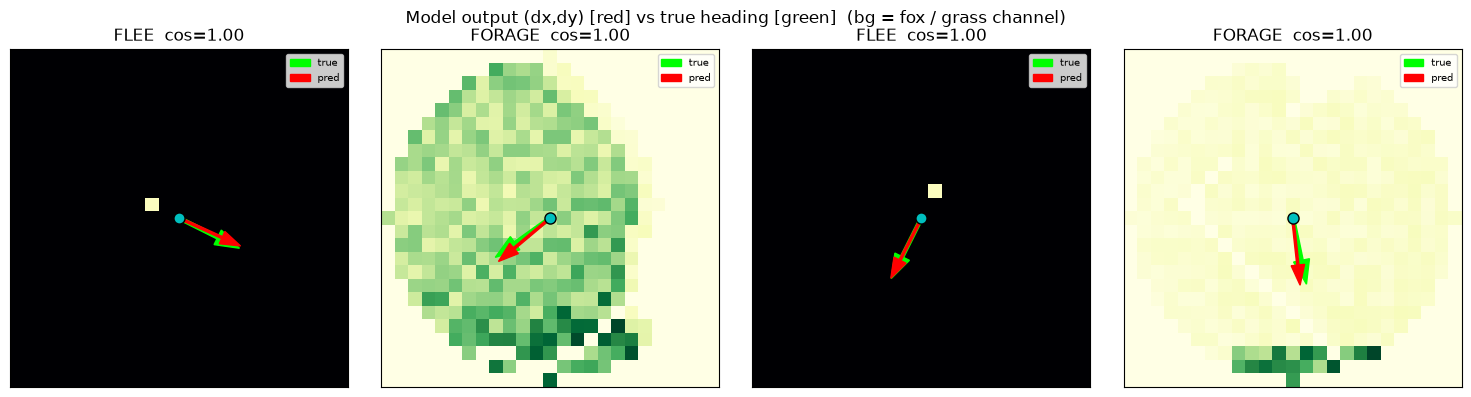

In [7]:
# Predicted (dx,dy) [red] vs true heading [green] on a few held-out views. Background is the
# decisive channel: the threat (fox) channel for flee scenes, the food (grass) channel for
# forage. Flee arrows point AWAY from the fox blip; forage arrows point toward the grass.
pick = np.random.default_rng(1).choice(len(va), size=4, replace=False)
c = WIN // 2
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
with torch.no_grad():
    for a, pi in zip(axes, pick):
        gi = va[pi]
        p = unit(model(torch.tensor(X[gi:gi+1]).to(device))).cpu().numpy()[0]
        tw = tgt[gi]; m = mode[gi]
        bg = X[gi, 2] if m == 1 else X[gi, 1]
        a.imshow(bg, origin="upper", cmap="magma" if m == 1 else "YlGn")
        a.plot(c, c, "co", ms=8, mec="k")
        a.arrow(c, c, tw[0]*5, tw[1]*5, color="lime", width=0.25, head_width=1.2,
                length_includes_head=True, label="true")
        a.arrow(c, c, p[0]*5, p[1]*5, color="red", width=0.16, head_width=1.0,
                length_includes_head=True, label="pred")
        a.set_title(f"{'FLEE' if m==1 else 'FORAGE'}  cos={float(p @ tw):.2f}")
        a.set_xticks([]); a.set_yticks([]); a.legend(loc="upper right", fontsize=7)
fig.suptitle("Model output (dx,dy) [red] vs true heading [green]  (bg = fox / grass channel)")
plt.tight_layout(); plt.show()

## Conclusion

A single CNN+FNN **outputs the `(dx, dy)` move direction directly** — the same quantity
`RuleBrain` produces — from the sheep's terrain + food + threat view alone, and it learns the
sheep's **arbitration**: it flees away from a nearby fox (even while hungry over grass) and
otherwise forages toward the grass. On held-out scenes the heading is accurate within each
mode, so a learned sheep brain can both evade predators and find food behind the
`Brain.decide(obs) → act` contract.

In [ ]:
torch.save(model.state_dict(), 'sheepvision.pt')